# Exploratory Data Analysis of Brent Oil Prices

This notebook performs an initial exploratory data analysis (EDA) of historical Brent crude oil prices.
The objective is to understand the time series properties of the data, including trends, volatility,
and stationarity considerations, in preparation for Bayesian Change Point Analysis.

This analysis forms part of the **Task 1 (Interim Submission)** for the 10 Academy AI Mastery Program.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

## Data Loading

The dataset contains daily Brent oil prices from 1987 to 2022.

In [5]:
data_path = "../data/raw/demo_prices.csv"
df = pd.read_csv(data_path)

df.head()

,date,price
0,2023-01-01,31.738500
1,2023-01-02,29.516075
2,2023-01-03,32.266910
3,2023-01-04,35.330604
4,2023-01-05,29.180463


In [8]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    400 non-null    datetime64[us]
 1   price   400 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 6.4 KB


## Data Quality Checks

Basic validation is performed to identify missing values, duplicate entries,
and unrealistic price values.


In [9]:
df.isna().sum()

df["date"].duplicated().sum()

df["price"].describe()

(df["price"] <= 0).sum()

np.int64(0)

## Brent Oil Price Over Time

The raw price series is visualized to identify long-term trends,
major shocks, and periods of high volatility.


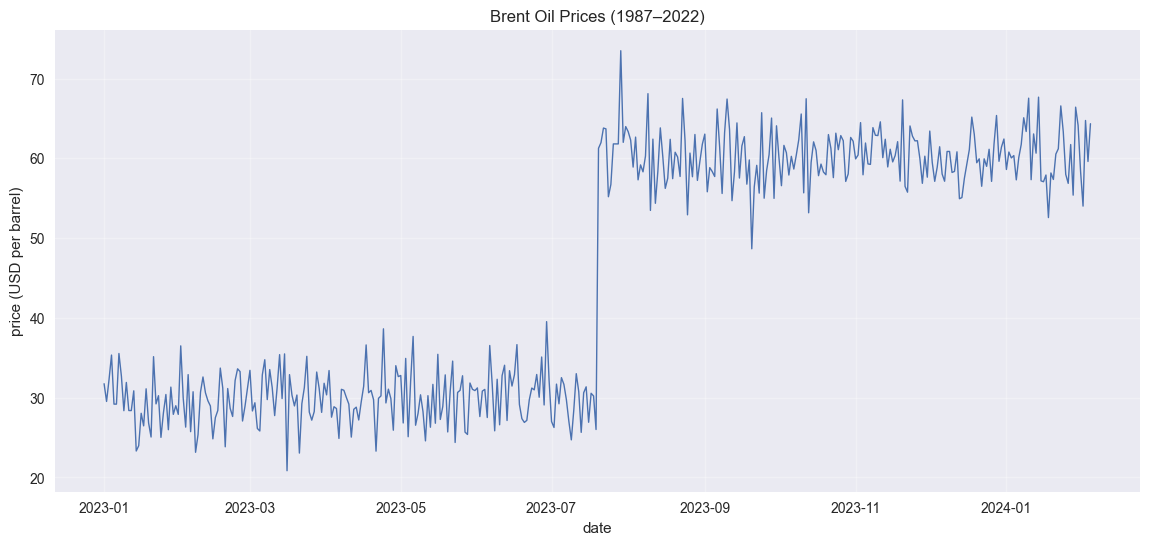

In [10]:
plt.figure(figsize=(14,6))
plt.plot(df["date"], df["price"], linewidth=1)
plt.title("Brent Oil Prices (1987–2022)")
plt.xlabel("date")
plt.ylabel("price (USD per barrel)")
plt.grid(True, alpha=0.3)
plt.show()

### Observations
- Brent oil prices exhibit strong long-term trends and regime shifts
- Periods of extreme volatility are visible, particularly around global crises
- The series is clearly non-stationary, motivating transformation before modeling


## Log Returns and Volatility

To stabilize variance and improve stationarity, log returns are computed.


In [12]:
df["log_return"] = np.log(df["price"]).diff()
df.dropna(inplace=True)

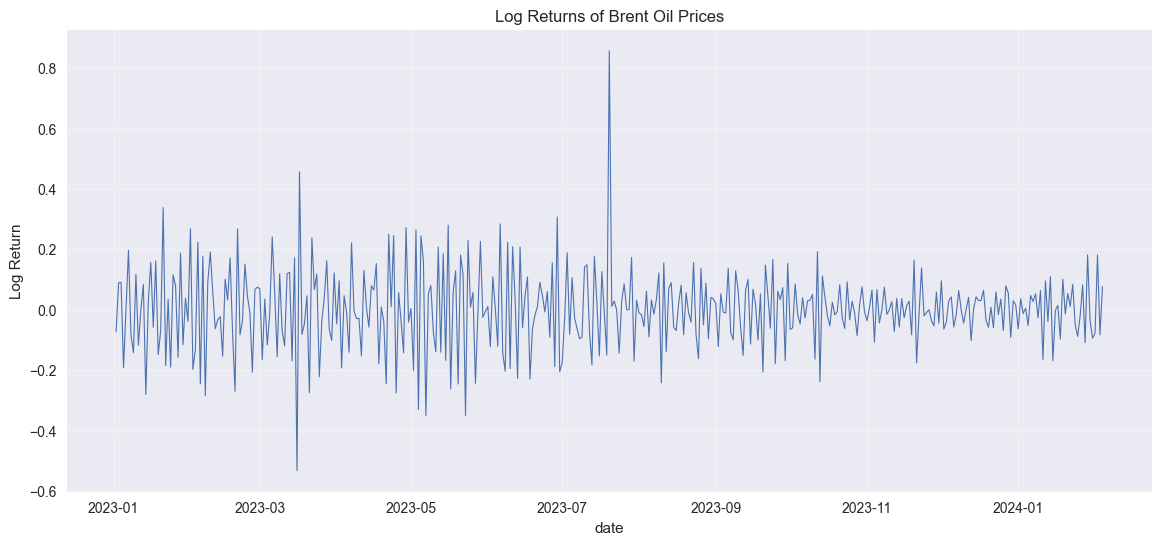

In [13]:
plt.figure(figsize=(14,6))
plt.plot(df["date"], df["log_return"], linewidth=0.8)
plt.title("Log Returns of Brent Oil Prices")
plt.xlabel("date")
plt.ylabel("Log Return")
plt.grid(True, alpha=0.3)
plt.show()


### Volatility Characteristics
- Log returns fluctuate around a near-zero mean
- Volatility clustering is evident, indicating changing risk regimes
- These properties support the use of change point models to detect structural breaks


## Interim Summary

This exploratory analysis shows that Brent oil prices are non-stationary and highly volatile,
with clear regime changes over time. Log return transformation reduces trend effects but reveals
volatility clustering.

These findings justify the use of Bayesian Change Point Analysis in subsequent modeling steps
to identify structural breaks and associate them with geopolitical and economic events.


## Assumptions and Limitations

### Assumptions
1. **Data Quality**: The historical Brent oil price data is assumed to be accurate, complete, and correctly timestamped.
2. **Event Impact**: Key geopolitical and economic events are assumed to have potential influence on oil prices during their respective time frames.
3. **Stationarity & Transformation**: Log returns are assumed to sufficiently stabilize variance for initial analysis.
4. **Single vs Multiple Change Points**: For demonstration purposes, single or a small number of structural breaks are modeled, acknowledging that real markets may have multiple overlapping factors.
5. **Independence of Observations**: Daily price changes are treated as conditionally independent given the modeled mean shifts.

### Limitations
1. **Correlation vs Causation**: Detected change points indicate structural shifts in prices but do not prove that a specific event caused the change.
2. **Event Timing Precision**: Some events have approximate start dates, which may not align exactly with the actual market impact.
3. **Simplified Modeling**: The initial Bayesian change point model assumes normally distributed returns and does not incorporate external macroeconomic variables.
4. **Data Coverage**: Analysis is limited to historical daily prices; intraday fluctuations and trading volumes are not included.
5. **Interim Scope**: Current notebooks use either synthetic data or initial EDA on raw Brent prices. Full causal analysis and multiple change point modeling will be completed in the final submission.
